# Sales Prediction for Advertising spend (in $1000) (Simple Linear Regression)

# 📌 Problem Statement
 - Build a model which predicts sales based on the money spent on TV platforms for marketing

# 📈 Workflow Architecture

# 📊 Data Structure

# Importing Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Dataset Loaded

In [36]:
df= pd.read_csv('Revenue.csv')
df


,Advertising Spend (in $1000),Sales Revenue (in $1000)
0,43.71,223.67
1,95.56,505.96
2,75.88,393.65
3,63.88,310.74
4,24.04,106.73
...,...,...
495,41.80,201.05
496,62.53,305.30
497,17.00,100.64
498,97.70,498.71


# Data Understanding

In [3]:
df.head()

,Advertising Spend (in $1000),Sales Revenue (in $1000)
0,43.71,223.67
1,95.56,505.96
2,75.88,393.65
3,63.88,310.74
4,24.04,106.73


In [4]:
df.tail()

,Advertising Spend (in $1000),Sales Revenue (in $1000)
495,41.80,201.05
496,62.53,305.30
497,17.00,100.64
498,97.70,498.71
499,98.76,521.50


In [41]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 500
Number of Columns: 2


In [6]:
df.columns

Index(['Advertising Spend (in $1000)', 'Sales Revenue (in $1000)'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Advertising Spend (in $1000)  500 non-null    float64
 1   Sales Revenue (in $1000)      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [8]:
df.dtypes

Advertising Spend (in $1000)    float64
Sales Revenue (in $1000)        float64
dtype: object

In [9]:
df.describe()

,Advertising Spend (in $1000),Sales Revenue (in $1000)
count,500.00000,500.000000
mean,54.87076,274.467080
std,26.88202,136.276157
min,10.46000,31.570000
25%,31.71750,157.965000
50%,56.18500,281.025000
75%,78.05250,393.380000
max,99.37000,521.500000


# Data Quality Check

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

Advertising Spend (in $1000)    0
Sales Revenue (in $1000)        0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

<Axes: >

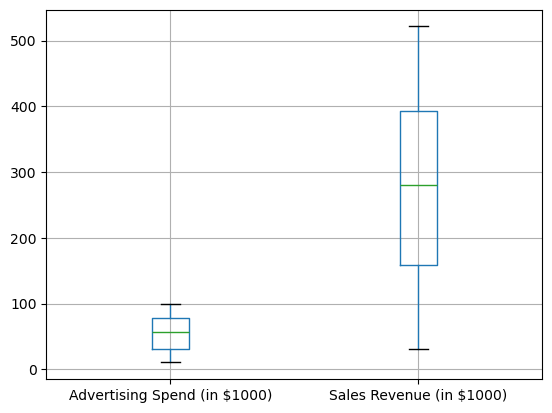

In [12]:
df.boxplot()

## Univariate Analysis

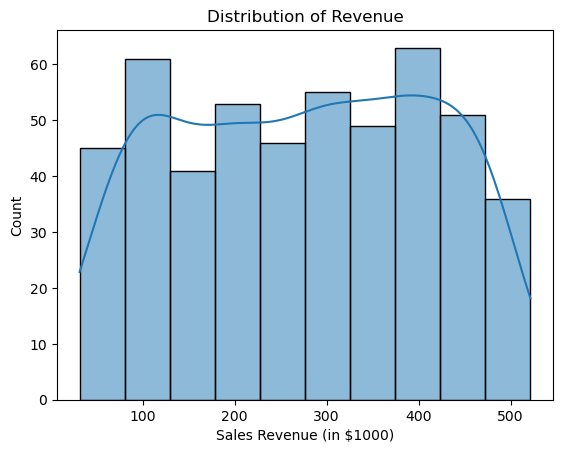

In [39]:
sns.histplot(df['Sales Revenue (in $1000)'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

# Bivariate Analysis
 - The scatter plot shows a strong positive linear relationship between Advertising Spend and Sales Revenue
 - he linear pattern indicates that Simple Linear Regression is an appropriate model for predicting sales revenue based on advertising spend.

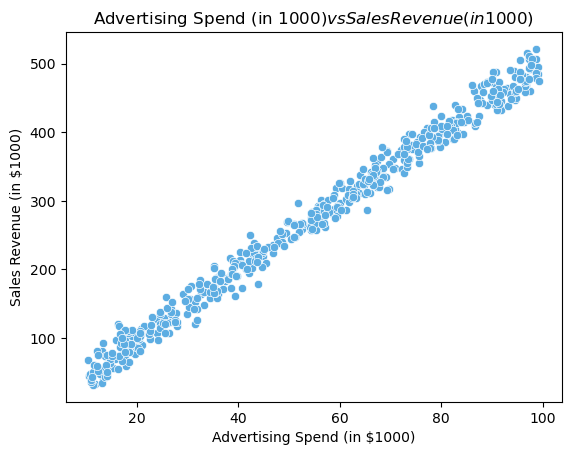

In [34]:
sns.scatterplot(x=df['Advertising Spend (in $1000)'],y=df['Sales Revenue (in $1000)'],color='#5DADE2')
plt.title('Advertising Spend (in $1000) vs Sales Revenue (in $1000)' )
plt.show()

# Correlation Analysis
 - A correlation coefficient of 0.99 indicates an extremely strong positive relationship between Advertising Spend and Sales Revenue. This suggests that higher advertising expenditure is associated with higher sales revenue

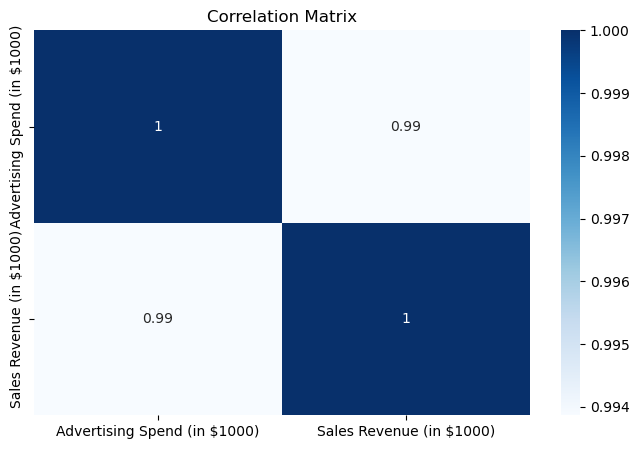

In [42]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

# Feature Selection


In [43]:
X=df[['Advertising Spend (in $1000)']] # independent variable
y=df['Sales Revenue (in $1000)'] # Target Column

# Model Building

In [16]:
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
print(f"Coefficient value: {lr.coef_}")
print(f"Slope value: {lr.intercept_}")

Coefficient value: [5.03831975]
Slope value: -1.9893539166222354


# Prediction

In [19]:
ypred=lr.predict(X)
ypred

array([218.23560244, 479.47248159, 380.31834887, 319.85851184,
       119.13185292, 119.13185292,  74.74425591, 441.18125147,
       320.96694219, 369.4859614 ,  57.71473514, 488.18877476,
       425.86475943, 144.67613406, 130.82075475, 131.57650271,
       186.34303841, 286.35368549, 244.28371556, 180.4482043 ,
       325.85411235, 111.62475649, 180.85126988, 214.50724583,
       255.21686942, 404.45190048, 138.93244955, 281.56728173,
       317.03705278,  69.45402017, 323.88916764, 125.7320518 ,
        77.86801415, 478.66635043, 486.27421325, 414.98198876,
       186.5445712 ,  92.68067422, 358.65357393, 247.96168898,
       103.71459448, 272.95175495,  63.96225164, 460.72993211,
       165.73631063, 348.82885042, 189.71871265, 284.2375912 ,
       296.2791754 , 132.23148428, 488.03762517, 399.8670295 ,
       474.38377864, 454.12973323, 319.50582946, 466.42323343,
        88.49886883, 137.26980403,  68.89980499, 195.91584594,
       224.63426853, 171.42961195, 424.20211391, 210.17

# Evaluation

In [20]:
mse=mean_squared_error(y,ypred)
mae=mean_absolute_error(y,ypred)
print(f"Mean_squared_error: {mse}")
print(f"Root_mean_squared_error: {np.sqrt(mse)}")
print(f"Mean_absolute_error: {mae}")
print(f"R2_score: {r2_score(y,ypred)}")

Mean_squared_error: 226.68527605646292
Root_mean_squared_error: 15.056071069720112
Mean_absolute_error: 12.090057664255367
R2_score: 0.9877692520568953


# Visualization of Results

In [45]:
df['Predicted Sales Revenue (in $1000)']=ypred
df.head()

,Advertising Spend (in $1000),Sales Revenue (in $1000),Predicted Sales Revenue (in $1000)
0,43.71,223.67,218.235602
1,95.56,505.96,479.472482
2,75.88,393.65,380.318349
3,63.88,310.74,319.858512
4,24.04,106.73,119.131853


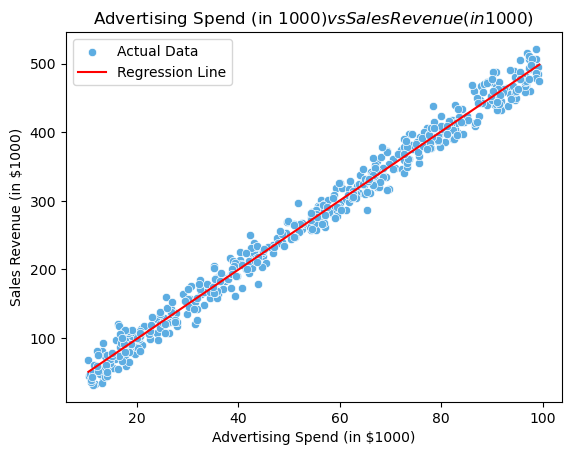

In [33]:
sns.scatterplot(x=df['Advertising Spend (in $1000)'],y=df['Sales Revenue (in $1000)'],color='#5DADE2',label='Actual Data')
sns.lineplot(x=df['Advertising Spend (in $1000)'],y=ypred, color='red', label='Regression Line')
plt.title('Advertising Spend (in $1000) vs Sales Revenue (in $1000)')
plt.legend()
plt.show()

# Final Model

In [57]:
print("╔══════════════════════════════════════════════╗")
print("║       FINAL MODEL PERFORMANCE SUMMARY        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  R² Score              : {r2_score(y, ypred)*100:>7.2f}%            ║")
print(f"║  MAE                   : {mae:>10.2f}          ║")
print(f"║  RMSE                  : {np.sqrt(mse):>10.2f}          ║")
print(f"║  Features Used         : {X.shape[1]:>10}          ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║       FINAL MODEL PERFORMANCE SUMMARY        ║
╠══════════════════════════════════════════════╣
║  R² Score              :   98.78%            ║
║  MAE                   :      12.09          ║
║  RMSE                  :      15.06          ║
║  Features Used         :          1          ║
╚══════════════════════════════════════════════╝


# Conclusion
 - The model achieved an R² Score of 0.9878, indicating that approximately 98.78% of the variation in Sales Revenue (in $1000) is explained by Advertising Spend. The low MAE and RMSE values suggest that the prediction errors are minimal, demonstrating high accuracy and reliability. Overall, the model successfully captures the strong linear relationship between Advertising Spend and Sales Revenue and is well-suited for revenue prediction